# OLS and the Inferential Toolkit

**Chapter 11 | Section 11.1**

**Docker image**: `ml4t`

This notebook shows what classical inference looks like before we leave it behind.
Using the same ETF features and labels as the rest of Chapter 11, we fit a
statsmodels OLS model and walk through the full inferential toolkit: coefficient
significance, Gauss-Markov diagnostics, and robust standard errors.

**Learning objectives**

- Interpret a statsmodels OLS summary: coefficients, standard errors, t-statistics, p-values
- Run the Gauss-Markov diagnostic battery (heteroscedasticity, serial correlation, normality)
- Identify multicollinearity via Variance Inflation Factors (VIF)
- Understand why inference diagnostics do not answer the prediction question

**Book reference**

Section 11.1 ("From Inference to Prediction"). The next notebook,
`02_regularization_paths`, transitions to the prediction-oriented framework.

**Prerequisites**

- Familiarity with linear regression and the Gauss-Markov assumptions.
- Conceptual exposure to heteroscedasticity, autocorrelation, and VIF.
- ETF case-study features at `case_studies/etfs/features/financial.parquet`
  (Ch8 output) and labels at `case_studies/etfs/labels/fwd_ret_21d.parquet`
  (Ch7 output).

## Setup

In [1]:
"""OLS and the Inferential Toolkit — classical inference diagnostics before the prediction pivot."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import statsmodels.api as sm
from ml4t.diagnostic.metrics import cross_sectional_ic_series
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.diagnostic import acorr_breusch_godfrey, het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson, jarque_bera

from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

In [2]:
SEED = 42
MAX_SYMBOLS = 0
MAX_TRAIN_ROWS = 0
VIF_MAX_ROWS = 0

In [3]:
set_global_seeds(SEED)

## Load Features and Labels

We use the same ETF case study data as the rest of Chapter 11: financial
features from Ch8 and 21-day forward return labels from Ch7.

In [4]:
CASE_DIR = get_case_study_dir("etfs")

FEATURES_PATH = CASE_DIR / "features" / "financial.parquet"
LABELS_PATH = CASE_DIR / "labels" / "fwd_ret_21d.parquet"

assert FEATURES_PATH.exists(), f"Features not found: {FEATURES_PATH}\nRun Ch8 ETF features first."
assert LABELS_PATH.exists(), f"Labels not found: {LABELS_PATH}\nRun Ch7 ETF labels first."

features_df = pl.read_parquet(FEATURES_PATH).with_columns(pl.col("timestamp").cast(pl.Date))
labels_df = pl.read_parquet(LABELS_PATH).with_columns(pl.col("timestamp").cast(pl.Date))

In [5]:
TARGET_COL = "fwd_ret_21d"
ASSET_COL = "symbol"

df = features_df.join(labels_df, on=["timestamp", ASSET_COL], how="inner")

META_COLS = {"timestamp", ASSET_COL, TARGET_COL}
FEATURE_COLS = sorted(c for c in df.columns if c not in META_COLS)

# Drop features that are entirely null (can happen with reduced test universes)
all_null = [c for c in FEATURE_COLS if df[c].null_count() == df.height]
if all_null:
    print(f"Dropping {len(all_null)} all-null features: {all_null}")
    df = df.drop(all_null)
    FEATURE_COLS = [c for c in FEATURE_COLS if c not in all_null]

# Replace inf/NaN with null, then drop all nulls
df = df.with_columns(
    [
        pl.when(pl.col(c).is_nan() | pl.col(c).is_infinite())
        .then(None)
        .otherwise(pl.col(c))
        .alias(c)
        for c in FEATURE_COLS
    ]
)
df = df.drop_nulls(subset=FEATURE_COLS + [TARGET_COL]).sort(["timestamp", ASSET_COL])

In [6]:
# Drop features that are exact linear combinations of others.
# Ch8 constructs skip_recent and mom_accel features as differences of return
# horizons (e.g., skip_recent_12_1 = ret_252d - ret_21d). Including both the
# raw returns and these derived differences makes the design matrix singular,
# which prevents computation of robust standard errors.
REDUNDANT = {
    "mom_accel_short",
    "mom_accel_medium",
    "mom_accel_long",
    "skip_recent_6_1",
    "skip_recent_12_1",
}
n_redundant = len(REDUNDANT & set(FEATURE_COLS))
FEATURE_COLS = [c for c in FEATURE_COLS if c not in REDUNDANT]
if n_redundant:
    print(f"Dropped {n_redundant} linearly dependent features (return-difference composites)")

if MAX_SYMBOLS > 0:
    assets = df[ASSET_COL].unique().sort().head(MAX_SYMBOLS).to_list()
    df = df.filter(pl.col(ASSET_COL).is_in(assets))

print(f"Shape: {df.height:,} rows x {len(FEATURE_COLS)} features")
print(f"Assets: {df[ASSET_COL].n_unique()}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

Dropped 5 linearly dependent features (return-difference composites)
Shape: 393,985 rows x 52 features
Assets: 99
Date range: 2007-01-04 to 2025-12-01


## Select a Single Training Fold

Inference is an in-sample exercise — we fit one model on one training window
and examine its properties. We use the first walk-forward fold and hold back
the validation set for a prediction comparison at the end.

In [7]:
splits = generate_cv_splits(df, case_study_id="etfs", label_buffer="21D", date_col="timestamp")

s = splits[0]
tr_start = np.datetime64(s["train_start"])
tr_end = np.datetime64(s["train_end"])
val_start = np.datetime64(s["val_start"])
val_end = np.datetime64(s["val_end"])

dates_np = df["timestamp"].to_numpy()
train_mask = (dates_np >= tr_start) & (dates_np <= tr_end)
val_mask = (dates_np >= val_start) & (dates_np <= val_end)

X_train_raw = df.filter(train_mask).select(FEATURE_COLS).to_numpy()
y_train = df.filter(train_mask)[TARGET_COL].to_numpy()
X_val_raw = df.filter(val_mask).select(FEATURE_COLS).to_numpy()
y_val = df.filter(val_mask)[TARGET_COL].to_numpy()

if MAX_TRAIN_ROWS > 0 and len(y_train) > MAX_TRAIN_ROWS:
    idx = np.random.default_rng(42).choice(len(y_train), size=MAX_TRAIN_ROWS, replace=False)
    X_train_raw = X_train_raw[idx]
    y_train = y_train[idx]
    print(f"Subsampled training rows to {MAX_TRAIN_ROWS:,} for faster diagnostics")

# Standardize features (fitted on training data only)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)

# Keep feature names for statsmodels output (x1/x2/... is hard to interpret).
X_train_df = pd.DataFrame(X_train, columns=FEATURE_COLS)
X_val_df = pd.DataFrame(X_val, columns=FEATURE_COLS)
y_train_s = pd.Series(y_train, name=TARGET_COL)

print(f"Training: {len(y_train):,} observations ({s['train_start']} to {s['train_end']})")
print(f"Validation: {len(y_val):,} observations ({s['val_start']} to {s['val_end']})")

Training: 226,959 observations (2012-12-31 00:00:00 to 2022-11-28 00:00:00)
Validation: 24,190 observations (2022-12-29 00:00:00 to 2023-12-29 00:00:00)


## Section 1: Statsmodels OLS Summary

Statsmodels provides the full inferential output that scikit-learn omits:
coefficient standard errors, t-statistics, p-values, and model-level diagnostics.

In [8]:
X_train_c = sm.add_constant(X_train_df, has_constant="add")
ols_model = sm.OLS(y_train_s, X_train_c).fit()

In [9]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:            fwd_ret_21d   R-squared:                       0.085
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     407.4
Date:                Fri, 12 Jun 2026   Prob (F-statistic):               0.00
Time:                        23:40:22   Log-Likelihood:             3.3690e+05
No. Observations:              226959   AIC:                        -6.737e+05
Df Residuals:                  226906   BIC:                        -6.731e+05
Df Model:                          52                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0058      0

**Reading the summary**: The coefficients table shows many features with small
p-values in the `P>|t|` column, which might seem to indicate "significant" predictors.
But the overall $R^2$ is very low — typical for cross-sectional return prediction.
A large sample (hundreds of thousands of observations) makes even tiny effects
"significant" in the statistical sense, while the economic magnitude may be
negligible. Note that even after removing the five exact linear combinations,
the remaining features are still pervasively correlated (as VIF will confirm),
so coefficient estimates are unstable across samples.

Crucially, these standard errors assume the **Gauss-Markov conditions** hold:
homoscedastic, uncorrelated errors with no multicollinearity. We now test each.

## Section 2: Gauss-Markov Diagnostic Battery

The Gauss-Markov theorem guarantees that OLS is the Best Linear Unbiased
Estimator (BLUE) — but only when its assumptions hold. Financial return data
routinely violates them. Each failed assumption has a specific consequence for
the reliability of standard errors and, therefore, t-statistics and p-values.

### Heteroscedasticity: Breusch-Pagan Test

Tests whether the error variance depends on the regressors. Financial returns
exhibit time-varying volatility (volatility clustering), so we expect rejection.

In [10]:
residuals = ols_model.resid
bp_stat, bp_pvalue, bp_fstat, bp_fpvalue = het_breuschpagan(residuals, X_train_c)

print(f"Breusch-Pagan LM statistic: {bp_stat:.1f}")
print(f"p-value: {bp_pvalue:.2e}")
print(f"F-statistic: {bp_fstat:.1f} (p = {bp_fpvalue:.2e})")

if bp_pvalue < 0.05:
    print("\nResult: REJECT homoscedasticity.")
    print("Consequence: OLS standard errors are biased — t-stats and p-values are unreliable.")
else:
    print("\nResult: Cannot reject homoscedasticity at 5% level.")

Breusch-Pagan LM statistic: 25956.2
p-value: 0.00e+00
F-statistic: 563.5 (p = 0.00e+00)

Result: REJECT homoscedasticity.
Consequence: OLS standard errors are biased — t-stats and p-values are unreliable.


### Serial Correlation: Durbin-Watson and Breusch-Godfrey

Panel data (multiple symbols observed on the same dates) creates cross-sectional
correlation, and financial returns exhibit short-term autocorrelation.
Durbin-Watson tests for first-order autocorrelation; Breusch-Godfrey extends
this to higher orders.

In [11]:
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw_stat:.4f}")
print("  (2.0 = no autocorrelation; <2 = positive; >2 = negative)")

bg_results = acorr_breusch_godfrey(ols_model, nlags=5)
bg_stat, bg_pvalue = bg_results[0], bg_results[1]
print(f"\nBreusch-Godfrey LM statistic (5 lags): {bg_stat:.1f}")
print(f"p-value: {bg_pvalue:.2e}")

if bg_pvalue < 0.05:
    print("\nResult: REJECT no serial correlation.")
    print("Consequence: OLS standard errors understate uncertainty — tests are too liberal.")
else:
    print("\nResult: Cannot reject no serial correlation at 5% level.")

Durbin-Watson statistic: 1.1447
  (2.0 = no autocorrelation; <2 = positive; >2 = negative)



Breusch-Godfrey LM statistic (5 lags): 69046.4
p-value: 0.00e+00

Result: REJECT no serial correlation.
Consequence: OLS standard errors understate uncertainty — tests are too liberal.


### Normality: Jarque-Bera Test

Tests whether residuals are normally distributed. Financial returns have fat
tails and excess kurtosis, so this will almost certainly reject.

In [12]:
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuals)

print(f"Jarque-Bera statistic: {jb_stat:.1f}")
print(f"p-value: {jb_pvalue:.2e}")
print(f"Skewness: {skew:.3f} (normal = 0)")
print(f"Excess kurtosis: {kurtosis:.3f} (normal = 0)")

if jb_pvalue < 0.05:
    print("\nResult: REJECT normality.")
    print("Consequence: Confidence intervals and F-tests based on normality are approximate.")
else:
    print("\nResult: Cannot reject normality at 5% level.")

Jarque-Bera statistic: 1123423.1
p-value: 0.00e+00
Skewness: -1.002 (normal = 0)
Excess kurtosis: 13.714 (normal = 0)

Result: REJECT normality.
Consequence: Confidence intervals and F-tests based on normality are approximate.


### Multicollinearity: Variance Inflation Factors

VIF measures how much each coefficient's variance is inflated by correlation
with other features. VIF > 5 is a common concern threshold; VIF > 10 indicates
severe multicollinearity. Financial features (momentum at different horizons,
volatility measures) are pervasively correlated.

In [13]:
X_vif = X_train_c
if VIF_MAX_ROWS > 0 and len(X_vif) > VIF_MAX_ROWS:
    idx = np.random.default_rng(43).choice(len(X_vif), size=VIF_MAX_ROWS, replace=False)
    X_vif = X_vif.iloc[idx]
    print(f"VIF computed on {VIF_MAX_ROWS:,} sampled rows")

x_vif_values = X_vif.to_numpy()
vif_values = [variance_inflation_factor(x_vif_values, i) for i in range(1, x_vif_values.shape[1])]
vif_df = pl.DataFrame({"feature": FEATURE_COLS, "vif": vif_values}).sort("vif", descending=True)

n_high = vif_df.filter(pl.col("vif") > 10).height
n_moderate = vif_df.filter((pl.col("vif") > 5) & (pl.col("vif") <= 10)).height

print(f"VIF > 10 (severe): {n_high} features")
print(f"VIF 5-10 (moderate): {n_moderate} features")
vif_df.head(15)

VIF > 10 (severe): 31 features
VIF 5-10 (moderate): 6 features


feature,vif
str,f64
"""rsi_14""",140.977485
"""sma_ratio_50""",112.043326
"""ema_ratio_26""",96.061843
"""rsi_7""",70.909052
"""bb_pctb_20""",66.459343
…,…
"""vol_21d""",25.17681
"""natr_14""",24.320012
"""sharpe_189d""",21.049435


High VIF confirms what Section 11.1 discusses: financial features are pervasively
correlated. Momentum at 5-day and 21-day horizons, different volatility measures,
and volume-price indicators share overlapping information. OLS distributes weight
arbitrarily among correlated features, producing unstable coefficient estimates
that flip sign across samples.

## Section 3: When Standard Errors Fail — Robust Alternatives

When Gauss-Markov assumptions fail, the coefficient estimates remain consistent
but their standard errors are wrong. Robust standard error methods fix inference
without changing the point estimates.

### Comparing Standard Error Estimates

We compare three standard error estimates:

- **OLS** (default): assumes homoscedastic, uncorrelated errors
- **HC3** (heteroscedasticity-consistent): corrects for non-constant variance
- **HAC (Newey-West)**: corrects for both heteroscedasticity and autocorrelation

In [14]:
ols_hc3 = sm.OLS(y_train_s, X_train_c).fit(cov_type="HC3")
ols_hac = sm.OLS(y_train_s, X_train_c).fit(cov_type="HAC", cov_kwds={"maxlags": 10})

# Compare SEs and t-stats for features (skip constant at index 0)
se_comparison = pl.DataFrame(
    {
        "feature": FEATURE_COLS,
        "coef": ols_model.params[1:],
        "se_ols": ols_model.bse[1:],
        "se_hc3": ols_hc3.bse[1:],
        "se_hac": ols_hac.bse[1:],
        "t_ols": ols_model.tvalues[1:],
        "t_hac": ols_hac.tvalues[1:],
    }
).with_columns(
    se_ratio_hac=pl.col("se_hac") / pl.col("se_ols"),
)

In [15]:
# Show features where robust SEs differ most from OLS SEs.
hac_ranked = (
    se_comparison.sort("se_ratio_hac", descending=True)
    .head(10)
    .select("feature", "coef", "se_ols", "se_hac", "se_ratio_hac", "t_ols", "t_hac")
)
hac_ranked

feature,coef,se_ols,se_hac,se_ratio_hac,t_ols,t_hac
str,f64,f64,f64,f64,f64,f64
"""ret_5d""",-0.000658,0.000265,0.000734,2.76472,-2.481031,-0.89739
"""ema_ratio_26""",-0.00461,0.001128,0.002983,2.643865,-4.085919,-1.545434
"""ret_10d""",0.002719,0.000405,0.001025,2.530263,6.71382,2.653408
"""sma_ratio_50""",0.009563,0.001219,0.002895,2.37563,7.847781,3.303453
"""corr_spy_tlt_63d""",-0.001787,0.000128,0.000294,2.300111,-13.961544,-6.069945
"""vol_21d""",-0.006437,0.000578,0.001287,2.227675,-11.143718,-5.002398
"""yield_curve_zscore""",0.001318,0.000148,0.000327,2.207801,8.891384,4.027258
"""regime""",0.005818,0.000187,0.000402,2.147636,31.056674,14.460866
"""ret_42d""",-0.006946,0.000617,0.001313,2.127805,-11.25366,-5.288859


In [16]:
# Count how many features change significance at 5% level
n_sig_ols = int((np.abs(ols_model.tvalues[1:]) > 1.96).sum())
n_sig_hac = int((np.abs(ols_hac.tvalues[1:]) > 1.96).sum())

print("\nFeatures significant at 5% level:")
print(f"  OLS standard errors: {n_sig_ols} / {len(FEATURE_COLS)}")
print(f"  HAC standard errors: {n_sig_hac} / {len(FEATURE_COLS)}")
print(f"  Difference: {n_sig_ols - n_sig_hac} features lose significance")


Features significant at 5% level:
  OLS standard errors: 45 / 52
  HAC standard errors: 37 / 52
  Difference: 8 features lose significance


### Coefficients with 95% HAC Confidence Intervals

Rank features by absolute coefficient magnitude and show robust 95% confidence
intervals around each estimate.

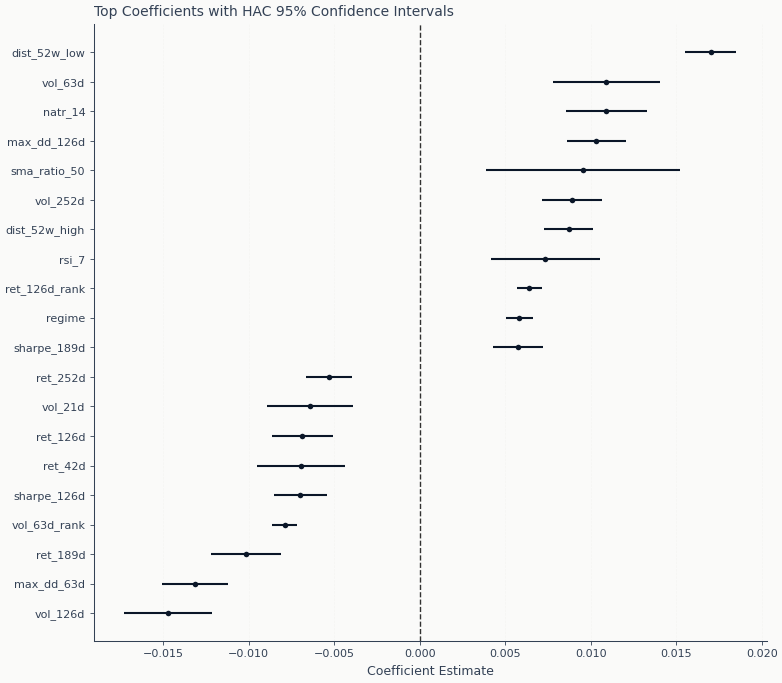

In [17]:
TOP_COEFS = 20

coef_plot = (
    se_comparison.with_columns(abs_coef=pl.col("coef").abs())
    .sort("abs_coef", descending=True)
    .head(TOP_COEFS)
    .sort("coef")
)

y_pos = np.arange(coef_plot.height)
coef_values = coef_plot["coef"].to_numpy()
hac_se = coef_plot["se_hac"].to_numpy()

fig, ax = plt.subplots(figsize=(8, 7))
ax.errorbar(
    x=coef_values,
    y=y_pos,
    xerr=1.96 * hac_se,
    fmt="o",
    capsize=3,
    linewidth=1.5,
    markersize=4,
)
ax.axvline(0.0, color="black", linestyle="--", linewidth=1.0, alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_plot["feature"].to_list())
ax.set_xlabel("Coefficient Estimate")
ax.set_title("Top Coefficients with HAC 95% Confidence Intervals")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Robust standard errors are typically *larger* than OLS standard errors, making
fewer features appear significant. This is the correct adjustment: OLS was
overstating precision by ignoring the correlation structure in the errors.

Beyond HAC, the econometric toolkit offers further specialized corrections:

- **WLS** (Weighted Least Squares): explicitly models heteroscedasticity when
  the variance function is known or estimable
- **GLS/FGLS** (Generalized / Feasible GLS): corrects for both heteroscedasticity
  and autocorrelation by transforming the model
- **Clustered standard errors**: accounts for within-group correlation (e.g.,
  by date or by asset) common in panel data

These are valuable tools for the data modeling culture — but they fix *inference*
quality, not *prediction* quality. A coefficient with correct standard errors
still tells you about in-sample relationships, not out-of-sample forecasting power.

## Section 4: Why This Doesn't Help Prediction

We now compute the one metric that matters for trading: the out-of-sample
Information Coefficient (IC). Because trading decisions rank assets at each
decision date, IC is computed cross-sectionally — Spearman rank correlation
between predicted and realized returns *within* each date — and then summarized
across the validation period via mean, IR ($\bar{IC} / \sigma_{IC}$), and a
t-statistic on the IC time series.

In [18]:
X_val_c = sm.add_constant(X_val_df, has_constant="add")
y_pred_val = np.asarray(ols_model.predict(X_val_c))

val_meta = df.filter(val_mask).select(["timestamp", ASSET_COL])
pred_df = val_meta.with_columns(prediction=pl.Series(y_pred_val))
ret_df = val_meta.with_columns(forward_return=pl.Series(y_val))

ic_per_date = cross_sectional_ic_series(
    pred_df,
    ret_df,
    pred_col="prediction",
    ret_col="forward_return",
    date_col="timestamp",
    entity_col=ASSET_COL,
)
ic_clean = ic_per_date.drop_nulls("ic")
ic_mean = float(ic_clean["ic"].mean())
ic_std = float(ic_clean["ic"].std())
n_periods = ic_clean.height
ic_ir = ic_mean / ic_std if ic_std > 0 else float("nan")
ic_t = ic_mean / (ic_std / np.sqrt(n_periods)) if ic_std > 0 else float("nan")

r2_train = ols_model.rsquared
r2_val = 1 - np.sum((y_val - y_pred_val) ** 2) / np.sum((y_val - y_val.mean()) ** 2)

print(f"In-sample R²:           {r2_train:.4f}")
print(f"Out-of-sample R²:       {r2_val:.4f}")
print(f"Out-of-sample IC mean:  {ic_mean:.4f}")
print(f"Out-of-sample IC IR:    {ic_ir:.2f}")
print(f"Out-of-sample IC t-stat: {ic_t:.2f}  (n={n_periods} dates)")
print(f"Significant features:   {n_sig_hac} (HAC-corrected)")

In-sample R²:           0.0854
Out-of-sample R²:       -0.1364
Out-of-sample IC mean:  0.0160
Out-of-sample IC IR:    0.07
Out-of-sample IC t-stat: 1.08  (n=252 dates)
Significant features:   37 (HAC-corrected)


### Validation Predictions and Residuals

The left panel compares predicted vs realized returns; the right panel shows
residuals against predictions. We sample for readability on large validation sets.

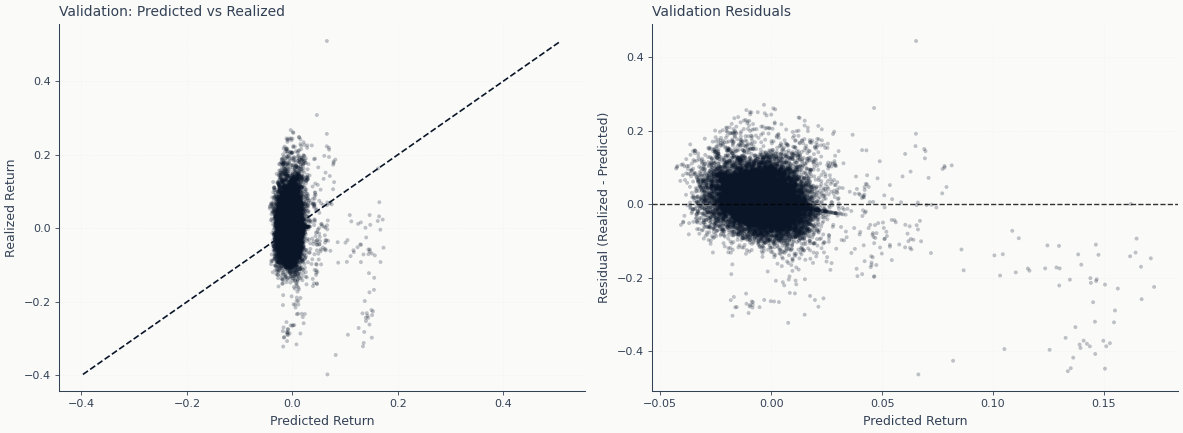

In [19]:
MAX_PLOT_POINTS = 20000
if len(y_val) > MAX_PLOT_POINTS:
    idx = np.random.default_rng(44).choice(len(y_val), size=MAX_PLOT_POINTS, replace=False)
    y_val_plot = y_val[idx]
    y_pred_plot = y_pred_val[idx]
else:
    y_val_plot = y_val
    y_pred_plot = y_pred_val

residuals_plot = y_val_plot - y_pred_plot

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(y_pred_plot, y_val_plot, s=8, alpha=0.25, edgecolor="none")
diag_min = min(y_pred_plot.min(), y_val_plot.min())
diag_max = max(y_pred_plot.max(), y_val_plot.max())
axes[0].plot([diag_min, diag_max], [diag_min, diag_max], linestyle="--", linewidth=1.2)
axes[0].set_xlabel("Predicted Return")
axes[0].set_ylabel("Realized Return")
axes[0].set_title("Validation: Predicted vs Realized")
axes[0].grid(alpha=0.3)

axes[1].scatter(y_pred_plot, residuals_plot, s=8, alpha=0.25, edgecolor="none")
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1.0, alpha=0.8)
axes[1].set_xlabel("Predicted Return")
axes[1].set_ylabel("Residual (Realized - Predicted)")
axes[1].set_title("Validation Residuals")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Why out-of-sample $R^2$ can go negative

Both in-sample and out-of-sample $R^2$ use the same formula:

$$R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}
      = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

The denominator $SS_{\text{tot}}$ measures total variance around the mean; the
numerator $SS_{\text{res}}$ measures residual variance after the model's
predictions. When $R^2 = 0$, the model is no better than predicting $\bar{y}$
for every observation.

**In-sample**, OLS with an intercept guarantees $R^2 \geq 0$. The intercept
ensures that the predicted mean equals the observed mean
($\bar{\hat{y}} = \bar{y}$), so the model can always do at least as well as
the constant-mean baseline. The fitted coefficients minimize $SS_{\text{res}}$
by construction.

**Out-of-sample**, both guarantees break. First, the coefficients were optimized
for the training set, not the validation set — they may amplify noise rather
than capture signal, making $SS_{\text{res}} > SS_{\text{tot}}$ and driving
$R^2$ below zero. Second, the intercept was calibrated to the training-period
mean return. If the validation period has a different mean (as it usually does
with non-stationary financial data), predictions are systematically shifted to
the wrong level. This level error inflates $SS_{\text{res}}$ even if the model
ranks returns correctly.

That is exactly what happens here: the negative out-of-sample $R^2$ means the
model's magnitude predictions are worse than the naive mean, driven by
overfitting 52 coefficients and a stale intercept. Yet the IC is positive —
the model ranks returns slightly better than chance. IC (Spearman rank
correlation) is invariant to level shifts and scaling, which is why it, not
$R^2$, is the standard metric for cross-sectional return prediction in
quantitative finance.

None of the diagnostic tests — Breusch-Pagan, Durbin-Watson, Jarque-Bera,
VIF — measure out-of-sample ranking accuracy. A coefficient can be statistically
significant yet contribute nothing to prediction (large sample, tiny effect), and
vice versa. The diagnostics tell us whether our *inference* about parameter
values is reliable; they say nothing about whether those parameters produce
useful *forecasts*.

This is the core insight of Section 11.1: the inferential toolkit and the
predictive toolkit answer different questions. For algorithmic trading, the
relevant question is "does this model rank future returns accurately?" — and
the relevant tool is out-of-sample evaluation, not hypothesis testing.

Section 11.2 introduces regularization — the tool that directly targets
prediction quality by trading bias for variance.

## Key Takeaways

1. **Statsmodels provides the full inferential toolkit**: standard errors,
   t-statistics, p-values, F-tests, and a battery of diagnostic tests that
   scikit-learn intentionally omits.

2. **The ETF feature set violates multiple Gauss-Markov assumptions**:
   heteroscedasticity (Breusch-Pagan rejects), serial correlation
   (Breusch-Godfrey rejects), non-normality (Jarque-Bera rejects), and
   multicollinearity (many features with VIF > 10).

3. **Robust standard errors (HAC, HC3) fix inference** by correcting for
   the violated assumptions, but they don't improve predictions.

4. **WLS, GLS, FGLS** address specific inference problems — specialized
   tools for the data modeling culture that improve parameter estimation
   under non-ideal conditions.

5. **For prediction, we need a different approach**: regularization +
   out-of-sample evaluation. The next notebook introduces Ridge, LASSO,
   and Elastic Net.

**Next**: `02_regularization_paths` introduces the prediction-oriented framework
with regularized regression and walk-forward cross-validation.